In [ ]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import  confusion_matrix, accuracy_score, precision_score, recall_score

In [3]:
df = pd.read_csv("../data.csv")

In [4]:
df_mod = df[df["type"].isin(["TRANSFER","CASH_OUT"])].copy()

df_mod['error_balance_orig'] = df_mod['newbalanceOrig'] + df_mod['amount'] - df_mod['oldbalanceOrg']
df_mod['error_balance_dest'] = df_mod['oldbalanceDest'] + df_mod['amount'] - df_mod['newbalanceDest']
df_mod['vacia_cuenta'] = np.where(df_mod['amount'] == df_mod['oldbalanceOrg'], 1, 0)

In [5]:
df_mod = pd.get_dummies(df_mod, columns=["type"], drop_first=True, dtype=int)

df_mod = df_mod.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

In [6]:
X = df_mod.drop(["isFraud","isFlaggedFraud","step"], axis=1,errors="ignore")

y = df_mod['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
modelo_fraude = RandomForestClassifier(n_estimators=100,max_depth=15 ,random_state=42, class_weight='balanced', n_jobs=-1)

modelo_fraude.fit(X_train, y_train)

print("Modelo entrenado")

Modelo entrenado


In [8]:
y_predict = modelo_fraude.predict(X_test)

In [9]:
print("acurracy score")
display(accuracy_score(y_test,y_predict))
print("exactitud")
display(precision_score(y_test,  y_predict))
print("recall score")
display(recall_score(y_test, y_predict))

acurracy score


0.999935027667385

exactitud


0.982003599280144

recall score


0.9963481436396835

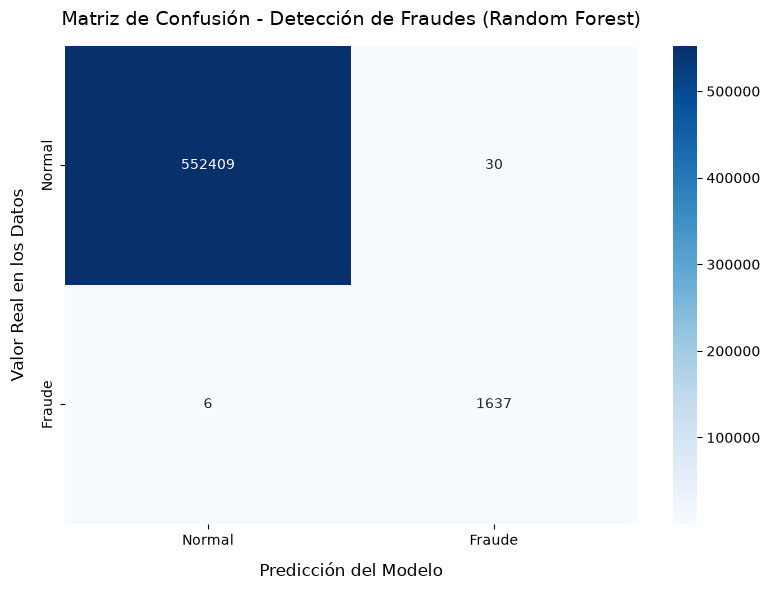

In [ ]:
cm = confusion_matrix(y_test, y_predict)

# Define el tamaño del lienzo del gráfico
plt.figure(figsize=(8, 6))

# annot=True: Escribe los números adentro de los cuadrados
# fmt='d': Formatea los números como enteros (sin decimales ni notación científica)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Fraude'], 
            yticklabels=['Normal', 'Fraude'])

plt.title('Matriz de Confusión - Detección de Fraudes (Random Forest)', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12, labelpad=10)
plt.ylabel('Valor Real en los Datos', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

In [10]:
import joblib 

joblib.dump(modelo_fraude,"../models/fraud_model.pkl")

['../models/fraud_model.pkl']